# ST2195 Assignment 8.1
## Replication of Assignment 7 in Python

This notebook replicates the exploratory data analysis performed in Assignment 7 using Python libraries including Pandas, Matplotlib, and Seaborn.

In [1]:
# ==========================================
# Assignment 8.1 - Titanic Data Analysis
# Replication of Assignment 7 in Python
# ==========================================

# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set plotting style
sns.set_theme(style="whitegrid")

In [2]:
# Load the Titanic dataset
df = pd.read_csv("titanic.csv")

# Convert all column names to lowercase
df.columns = df.columns.str.lower()

# Display the first five rows
df.head()

,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1216,3,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,13,NaN,NaN,1
1,699,3,"Cacic, Mr. Luka",male,38.0,0,0,315089,8.6625,NaN,S,NaN,NaN,Croatia,0
2,1267,3,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN,0
3,449,2,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,29105,23.0000,NaN,S,4,NaN,"Cornwall / Akron, OH",1
4,576,2,"Veal, Mr. James",male,40.0,0,0,28221,13.0000,NaN,S,NaN,NaN,"Barre, Co Washington, VT",0


In [3]:
# Check the dataset
print(df.columns.tolist())

['passenger_id', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest', 'survived']


In [4]:
# Convert variables to more readable labels

df["survived"] = df["survived"].map({
    0: "Died",
    1: "Survived"
})

df["pclass"] = df["pclass"].map({
    1: "1st Class",
    2: "2nd Class",
    3: "3rd Class"
})

# Check the changes
df.head()

,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1216,3rd Class,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,13,NaN,NaN,Survived
1,699,3rd Class,"Cacic, Mr. Luka",male,38.0,0,0,315089,8.6625,NaN,S,NaN,NaN,Croatia,Died
2,1267,3rd Class,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN,Died
3,449,2nd Class,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,29105,23.0000,NaN,S,4,NaN,"Cornwall / Akron, OH",Survived
4,576,2nd Class,"Veal, Mr. James",male,40.0,0,0,28221,13.0000,NaN,S,NaN,NaN,"Barre, Co Washington, VT",Died


## 1. Bar Charts for Gender, Passenger Class, and Survival

This section reproduces the bar charts from Assignment 7 in R. The charts display the distributions of passenger gender, passenger class, and survival status in the Titanic dataset.

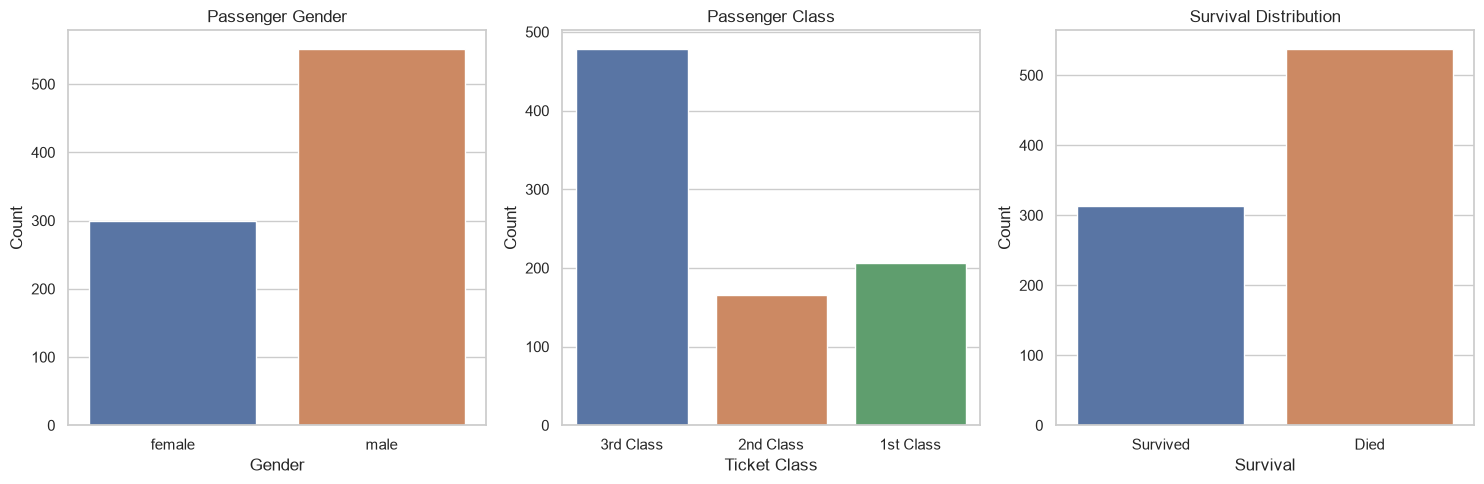

In [5]:
# ==========================================
# 1. Bar Charts for Gender, Ticket Class, and Survival
# ==========================================

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gender
sns.countplot(data=df, x="sex", hue="sex", ax=axes[0], legend=False)
axes[0].set_title("Passenger Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

# Ticket Class
sns.countplot(data=df, x="pclass", hue="pclass", ax=axes[1], legend=False)
axes[1].set_title("Passenger Class")
axes[1].set_xlabel("Ticket Class")
axes[1].set_ylabel("Count")

# Survival
sns.countplot(data=df, x="survived", hue="survived", ax=axes[2], legend=False)
axes[2].set_title("Survival Distribution")
axes[2].set_xlabel("Survival")
axes[2].set_ylabel("Count")

# Adjust spacing
plt.tight_layout()

# Display the plots
plt.show()

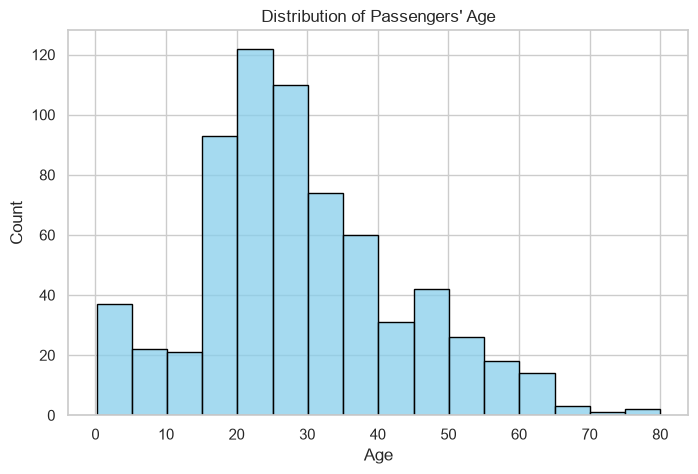

In [6]:
# ==========================================
# 2. Age Histogram
# ==========================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    binwidth=5,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Passengers' Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

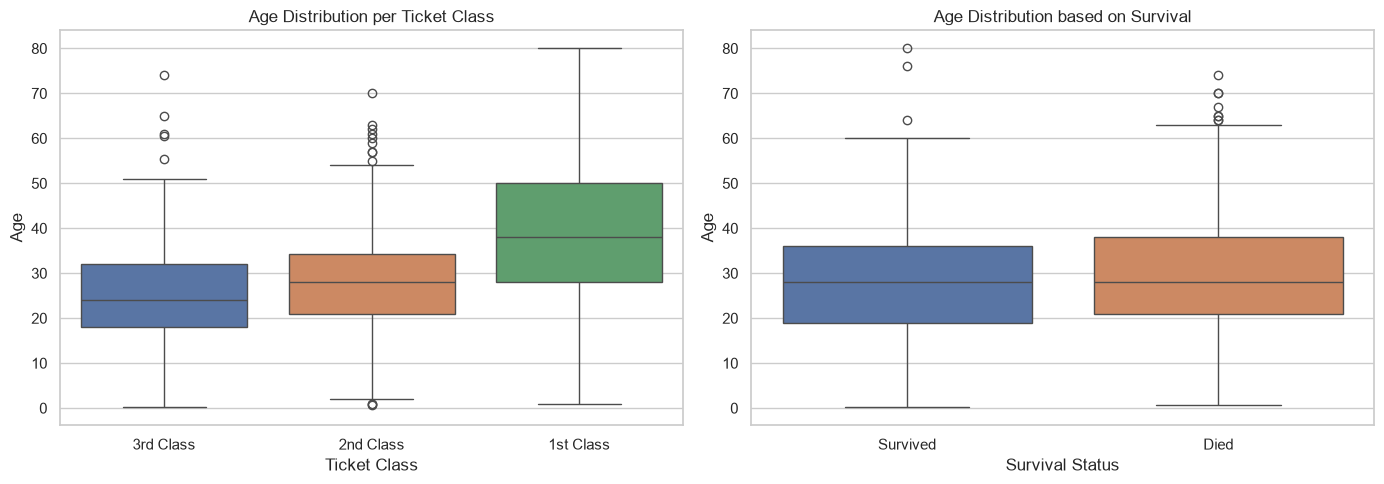

In [7]:
# ==========================================
# 3. Age Boxplots
# ==========================================

# Create two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by Passenger Class
sns.boxplot(
    data=df,
    x="pclass",
    y="age",
    hue="pclass",
    ax=axes[0],
    legend=False
)

axes[0].set_title("Age Distribution per Ticket Class")
axes[0].set_xlabel("Ticket Class")
axes[0].set_ylabel("Age")

# Age by Survival
sns.boxplot(
    data=df,
    x="survived",
    y="age",
    hue="survived",
    ax=axes[1],
    legend=False
)

axes[1].set_title("Age Distribution based on Survival")
axes[1].set_xlabel("Survival Status")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()

## 4. Fare Histogram and Free Passengers

This section displays the distribution of ticket fares and identifies passengers who travelled free of charge (fare = 0).

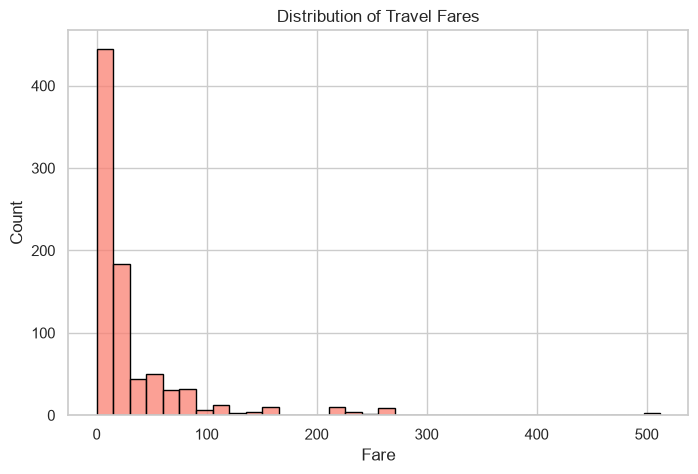

In [8]:
# ==========================================
# 4. Fare Histogram & Free Passengers
# ==========================================

# Fare histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="fare",
    binwidth=15,
    color="salmon",
    edgecolor="black"
)

plt.title("Distribution of Travel Fares")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

In [9]:
# Find passengers who paid no fare
free_passengers = df[df["fare"] == 0]

print("Number of passengers who did not pay:")
print(len(free_passengers))

# Display the table
free_passengers

Number of passengers who did not pay:
11


,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
6,898,3rd Class,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,NaN,S,NaN,NaN,NaN,Died
95,150,1st Class,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,B94,S,NaN,110.0,NaN,Died
114,170,1st Class,"Ismay, Mr. Joseph Bruce",male,49.0,0,0,112058,0.0,B52 B54 B56,S,C,NaN,Liverpool,Survived
140,70,1st Class,"Chisholm, Mr. Roderick Robert Crispin",male,NaN,0,0,112051,0.0,NaN,S,NaN,NaN,"Liverpool, England / Belfast",Died
145,896,3rd Class,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,NaN,S,NaN,NaN,NaN,Died
340,223,1st Class,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0,NaN,S,NaN,NaN,Belfast,Died
346,234,1st Class,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0,NaN,S,NaN,NaN,"Rotterdam, Netherlands",Died
506,125,1st Class,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0,B102,S,NaN,NaN,NaN,Died
586,963,3rd Class,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,NaN,S,NaN,NaN,NaN,Died
703,410,2nd Class,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0,NaN,S,NaN,NaN,Belfast,Died


In [10]:
# Save the table as a CSV file
free_passengers.to_csv("free_passengers.csv", index=False)

print("free_passengers.csv has been saved.")

free_passengers.csv has been saved.


## 5. Family Size

Family Size is calculated as the total number of siblings/spouses and parents/children travelling together, plus the passenger.

In [11]:
# ==========================================
# 5. Family Size
# ==========================================

# Create Family Size feature
df["familysize"] = df["sibsp"] + df["parch"] + 1

# Display the first five rows
df[["sibsp", "parch", "familysize"]].head()

,sibsp,parch,familysize
0,0,0,1
1,0,0,1
2,1,1,3
3,1,3,5
4,0,0,1


## 6. Family Size per Ticket Class

This plot shows the distribution of family sizes across the three passenger classes.

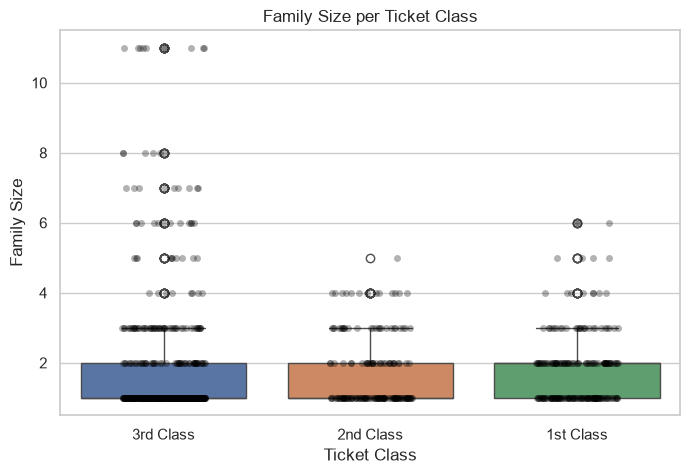

In [12]:
# ==========================================
# 6. Family Size per Ticket Class
# ==========================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pclass",
    y="familysize",
    hue="pclass",
    legend=False
)

sns.stripplot(
    data=df,
    x="pclass",
    y="familysize",
    color="black",
    alpha=0.3,
    jitter=0.2
)

plt.title("Family Size per Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Family Size")

plt.show()

## 7. Survival Rate by Gender and Ticket Class

This stacked bar chart shows the survival rate by passenger class, separated by gender.

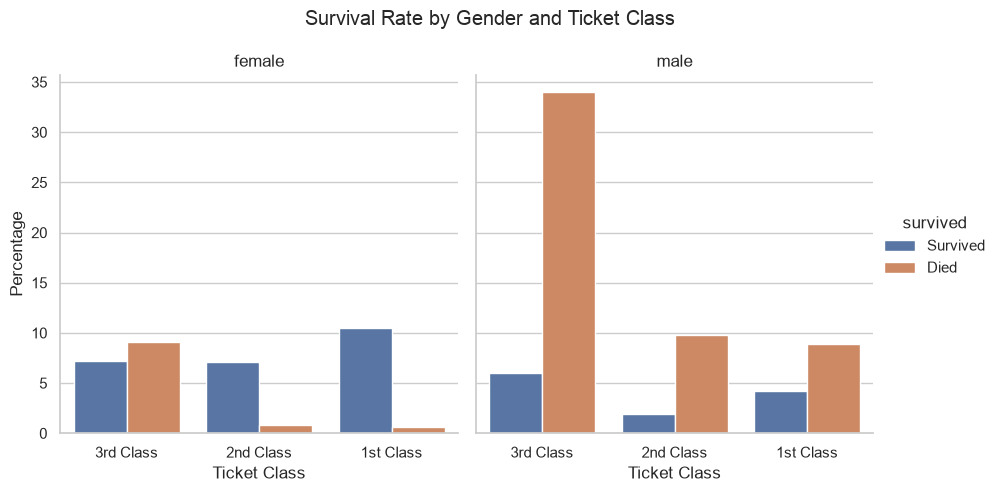

In [13]:
# ==========================================
# 7. Survival Rate by Gender and Ticket Class
# ==========================================

g = sns.catplot(
    data=df,
    x="pclass",
    hue="survived",
    col="sex",
    kind="count",
    stat="percent",
    height=5,
    aspect=0.9
)

g.set_titles("{col_name}")
g.set_axis_labels("Ticket Class", "Percentage")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Survival Rate by Gender and Ticket Class")

plt.show()

## 8. Survival Distribution by Age and Gender

This violin plot illustrates the distribution of passenger ages by survival status and gender.

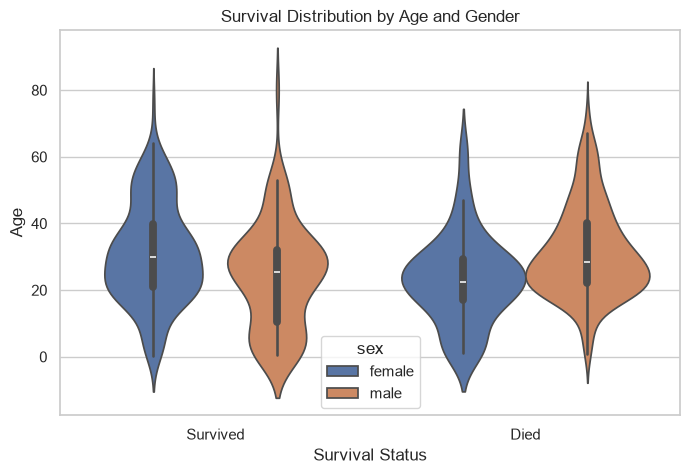

In [14]:
# ==========================================
# 8. Survival Distribution by Age and Gender
# ==========================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="survived",
    y="age",
    hue="sex"
)

plt.title("Survival Distribution by Age and Gender")
plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.show()

## 9. Survival Distribution by Age and Ticket Class

This violin plot illustrates the distribution of passenger ages by survival status and ticket class.

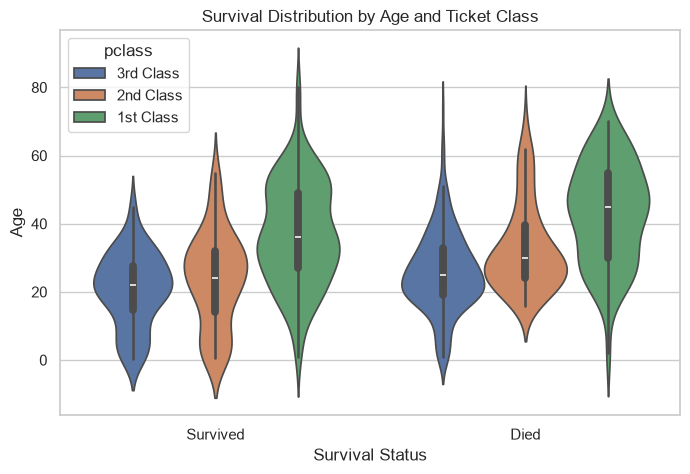

In [15]:
# ==========================================
# 9. Survival Distribution by Age and Ticket Class
# ==========================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="survived",
    y="age",
    hue="pclass"
)

plt.title("Survival Distribution by Age and Ticket Class")
plt.xlabel("Survival Status")
plt.ylabel("Age")

plt.show()

In [16]:
# Display the final dataset
df.head()

,passenger_id,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived,familysize
0,1216,3rd Class,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,13,NaN,NaN,Survived,1
1,699,3rd Class,"Cacic, Mr. Luka",male,38.0,0,0,315089,8.6625,NaN,S,NaN,NaN,Croatia,Died,1
2,1267,3rd Class,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,1,1,345773,24.1500,NaN,S,NaN,NaN,NaN,Died,3
3,449,2nd Class,"Hocking, Mrs. Elizabeth (Eliza Needs)",female,54.0,1,3,29105,23.0000,NaN,S,4,NaN,"Cornwall / Akron, OH",Survived,5
4,576,2nd Class,"Veal, Mr. James",male,40.0,0,0,28221,13.0000,NaN,S,NaN,NaN,"Barre, Co Washington, VT",Died,1
